# Linear Regression from Scratch

**Learning Objectives:**
- Understand what linear regression is and when to use it
- Develop deep intuitions about the Mean Squared Error (MSE) loss function
- Master gradient descent optimization from first principles
- Learn the analytical (closed-form) solution
- Compare approaches and understand their tradeoffs

By the end of this notebook, you'll have **strong, solid intuitions** about how linear regression works, both mathematically and geometrically.

## Part 1: What is Linear Regression?

Linear regression is one of the simplest and most powerful tools in machine learning. At its core, it answers a fundamental question:

**"How can we find the best straight line (or hyperplane) through our data?"**

### Real-World Examples

1. **Predicting house prices** from square footage
2. **Estimating crop yield** from rainfall amount
3. **Forecasting sales** from advertising spend
4. **Predicting test scores** from hours studied

In each case, we have:
- **Input (feature)**: square footage, rainfall, ad spend, study hours
- **Output (target)**: price, yield, sales, score
- **Goal**: Find a linear relationship between them

In [1]:
# Setup
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
from aiml_notebooks import set_seed

# Set seed for reproducibility
set_seed(42)

# Configure matplotlib for better-looking plots
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print("✓ Libraries loaded and seed set for reproducibility")

✓ Libraries loaded and seed set for reproducibility


## Part 2: Problem Setup

### The Components

For linear regression, we need:

1. **Dataset**: $\{(x^{(i)}, y^{(i)})\}_{i=1}^{n}$ where:
   - $x^{(i)}$ = input feature (e.g., square footage)
   - $y^{(i)}$ = target value (e.g., price)
   - $n$ = number of examples

2. **Hypothesis Function**: $h_\theta(x) = \theta_0 + \theta_1 x$
   - $\theta_0$ = intercept (bias)
   - $\theta_1$ = slope (weight)
   - This is our "prediction" or "model"

3. **Goal**: Find the best values of $\theta_0$ and $\theta_1$ that make our predictions close to the actual values.

### The Question

**How do we measure "best"?** That's where the loss function comes in!

In [2]:
# Generate synthetic 1D dataset
def generate_1d_data(n=100, theta_0_true=2.0, theta_1_true=3.0, noise_std=1.0):
    """
    Generate synthetic data following: y = theta_0 + theta_1 * x + noise
    
    Args:
        n: number of samples
        theta_0_true: true intercept
        theta_1_true: true slope
        noise_std: standard deviation of noise
    
    Returns:
        X: features (n,)
        y: targets (n,)
    """
    X = np.random.uniform(0, 10, n)
    y = theta_0_true + theta_1_true * X + np.random.normal(0, noise_std, n)
    return X, y

# Generate our dataset
X, y = generate_1d_data(n=100, theta_0_true=2.0, theta_1_true=3.0, noise_std=2.0)

print(f"Dataset shape: X={X.shape}, y={y.shape}")
print(f"X range: [{X.min():.2f}, {X.max():.2f}]")
print(f"y range: [{y.min():.2f}, {y.max():.2f}]")

Dataset shape: X=(100,), y=(100,)
X range: [0.06, 9.87]
y range: [1.52, 33.17]


## Part 3: Visualizing the Data

Let's see what our data looks like. Can you spot a linear relationship?

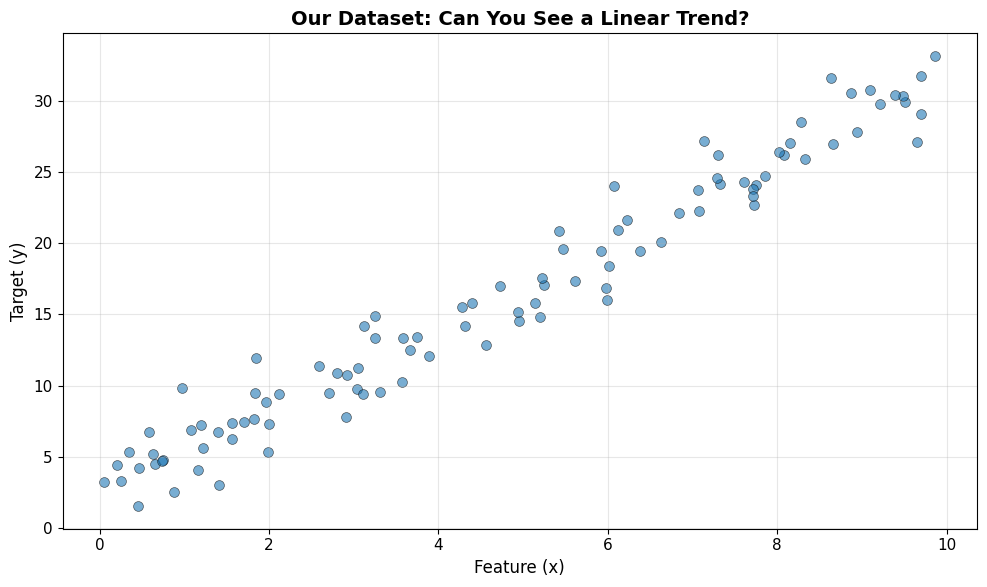

In [3]:
# Plot the data
plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
plt.xlabel('Feature (x)', fontsize=12)
plt.ylabel('Target (y)', fontsize=12)
plt.title('Our Dataset: Can You See a Linear Trend?', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 🤔 Reflection Question

**Q:** Looking at the plot above, roughly where would you draw a line through the data? What slope and intercept would you guess?

**Note:** The data was generated with $\theta_0 = 2$ and $\theta_1 = 3$ (plus some random noise). Let's see if we can recover these values!

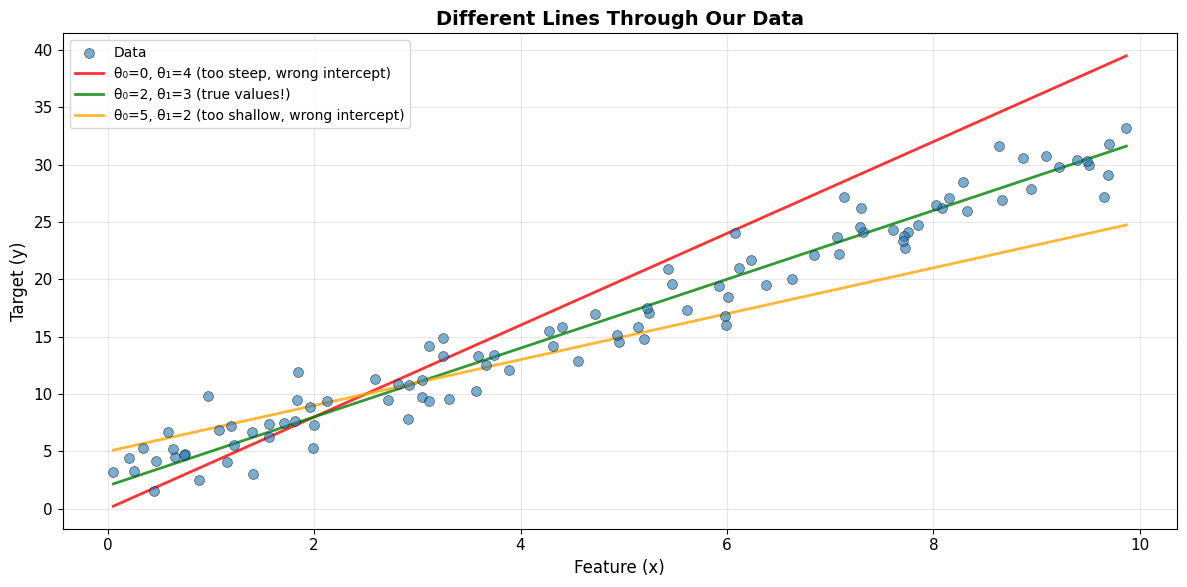

In [4]:
# Let's plot a few candidate lines
plt.figure(figsize=(12, 6))

# Try three different lines
candidates = [
    (0, 4, 'red', 'θ₀=0, θ₁=4 (too steep, wrong intercept)'),
    (2, 3, 'green', 'θ₀=2, θ₁=3 (true values!)'),
    (5, 2, 'orange', 'θ₀=5, θ₁=2 (too shallow, wrong intercept)')
]

x_line = np.linspace(X.min(), X.max(), 100)

plt.scatter(X, y, alpha=0.6, s=50, edgecolors='black', linewidth=0.5, label='Data', zorder=5)

for theta_0, theta_1, color, label in candidates:
    y_line = theta_0 + theta_1 * x_line
    plt.plot(x_line, y_line, color=color, linewidth=2, label=label, alpha=0.8)

plt.xlabel('Feature (x)', fontsize=12)
plt.ylabel('Target (y)', fontsize=12)
plt.title('Different Lines Through Our Data', fontsize=14, fontweight='bold')
plt.legend(loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Key Insight

The green line (true values) looks like the best fit! But how do we **quantify** "best"? We need a mathematical way to measure how good a line is.

That's where the **loss function** comes in.

## Part 4: The Loss Function (Mean Squared Error)

### The Idea

A loss function measures **how wrong** our predictions are. For linear regression, we typically use **Mean Squared Error (MSE)**:

$$J(\theta_0, \theta_1) = \frac{1}{n} \sum_{i=1}^{n} (h_\theta(x^{(i)}) - y^{(i)})^2$$

$$= \frac{1}{n} \sum_{i=1}^{n} (\theta_0 + \theta_1 x^{(i)} - y^{(i)})^2$$

### Breaking It Down

1. **Error for one example**: $e^{(i)} = h_\theta(x^{(i)}) - y^{(i)}$ = (prediction - actual)
2. **Squared error**: $(e^{(i)})^2$ = makes all errors positive, penalizes big errors more
3. **Average**: $\frac{1}{n}\sum$ = gives us the mean

### Why Square the Errors?

1. **Makes all errors positive** (otherwise positive and negative errors cancel out)
2. **Penalizes large errors more** (error of 2 → squared = 4, error of 4 → squared = 16)
3. **Mathematically convenient** (smooth, differentiable, has a unique minimum)

In [5]:
# Implement the MSE loss function
def compute_mse(X, y, theta_0, theta_1):
    """
    Compute Mean Squared Error for linear regression.
    
    Args:
        X: features (n,)
        y: targets (n,)
        theta_0: intercept
        theta_1: slope
    
    Returns:
        mse: mean squared error
    """
    n = len(X)
    predictions = theta_0 + theta_1 * X
    errors = predictions - y
    mse = (1/n) * np.sum(errors**2)
    return mse

# Test it on our candidate lines
print("Loss (MSE) for different lines:\n")
for theta_0, theta_1, color, label in candidates:
    loss = compute_mse(X, y, theta_0, theta_1)
    print(f"{label:50s} → MSE = {loss:8.3f}")

print("\n✓ Lower MSE = better fit!")

Loss (MSE) for different lines:

θ₀=0, θ₁=4 (too steep, wrong intercept)            → MSE =   20.985
θ₀=2, θ₁=3 (true values!)                          → MSE =    3.300
θ₀=5, θ₁=2 (too shallow, wrong intercept)          → MSE =   13.339

✓ Lower MSE = better fit!


### 🤔 Reflection Question

**Q:** Which line has the lowest MSE? Does this match your visual intuition from the plot above?

**Q:** Why is the MSE not exactly zero for the true parameters? (Hint: think about the noise we added!)

## Part 5: Visualizing the Loss Landscape

Now for something really cool: let's visualize the MSE as a function of $\theta_0$ and $\theta_1$.

This creates a **loss surface** (or loss landscape) in 3D!

In [6]:
# Create a grid of theta values
theta_0_range = np.linspace(-2, 6, 100)
theta_1_range = np.linspace(0.5, 5.5, 100)
theta_0_grid, theta_1_grid = np.meshgrid(theta_0_range, theta_1_range)

# Compute MSE for each combination
mse_grid = np.zeros_like(theta_0_grid)
for i in range(len(theta_0_range)):
    for j in range(len(theta_1_range)):
        mse_grid[j, i] = compute_mse(X, y, theta_0_grid[j, i], theta_1_grid[j, i])

print(f"Loss landscape computed: {mse_grid.shape}")
print(f"MSE range: [{mse_grid.min():.2f}, {mse_grid.max():.2f}]")

Loss landscape computed: (100, 100)
MSE range: [3.23, 310.36]


Execute the following code:

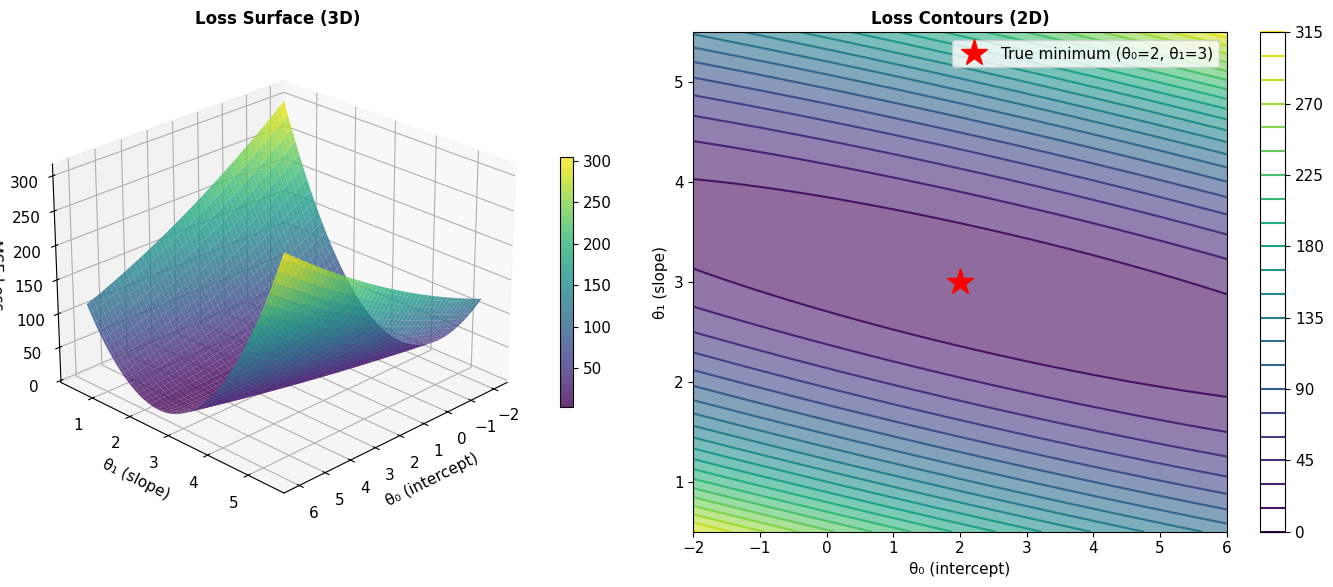

In [7]:
# 3D surface plot
fig = plt.figure(figsize=(14, 6))

# Surface plot
ax1 = fig.add_subplot(121, projection='3d')
surf = ax1.plot_surface(theta_0_grid, theta_1_grid, mse_grid, 
                        cmap=cm.viridis, alpha=0.8, edgecolor='none')
ax1.set_xlabel('θ₀ (intercept)', fontsize=11)
ax1.set_ylabel('θ₁ (slope)', fontsize=11)
ax1.set_zlabel('MSE Loss', fontsize=11)
ax1.set_title('Loss Surface (3D)', fontsize=12, fontweight='bold')
ax1.view_init(elev=25, azim=45)
fig.colorbar(surf, ax=ax1, shrink=0.5)

# Contour plot
ax2 = fig.add_subplot(122)
contour = ax2.contour(theta_0_grid, theta_1_grid, mse_grid, levels=20, cmap=cm.viridis)
ax2.contourf(theta_0_grid, theta_1_grid, mse_grid, levels=20, cmap=cm.viridis, alpha=0.6)
ax2.plot(2, 3, 'r*', markersize=20, label='True minimum (θ₀=2, θ₁=3)')
ax2.set_xlabel('θ₀ (intercept)', fontsize=11)
ax2.set_ylabel('θ₁ (slope)', fontsize=11)
ax2.set_title('Loss Contours (2D)', fontsize=12, fontweight='bold')
ax2.legend(loc='upper right')
fig.colorbar(contour, ax=ax2)

plt.tight_layout()
plt.show()

### Key Insights from the Loss Landscape

1. **Bowl shape**: The loss surface looks like a bowl or valley
2. **Single minimum**: There's one lowest point (the red star)
3. **Convex**: No local minima, just one global minimum
4. **Contours**: Each contour line represents points with the same loss

**Our goal**: Find the bottom of this bowl! This is where the best parameters live.

### 🤔 Reflection Question

**Q:** If you started at a random point on this surface and wanted to reach the minimum, which direction would you move? How would you decide?

## Part 6: Gradient Descent - The Intuition

Imagine you're blindfolded on a hill and want to reach the bottom (valley). What would you do?

**Strategy**: 
1. Feel the slope beneath your feet
2. Take a step in the downhill direction
3. Repeat until you reach the bottom

This is exactly what **gradient descent** does!

### The Algorithm (Intuitive)

1. **Start** somewhere random (or with a guess)
2. **Look** at the slope (gradient) at your current position
3. **Step** in the opposite direction of the slope (downhill)
4. **Repeat** until you reach the bottom (convergence)

### Key Concepts

- **Gradient**: The direction of steepest ascent (we go opposite direction)
- **Learning rate**: How big each step is
- **Convergence**: When we've reached the minimum (or close enough)

## Part 7: Computing the Gradient

To implement gradient descent, we need to compute the **gradient** of the loss function.

The gradient tells us:
- **Direction**: Which way is uphill?
- **Magnitude**: How steep is it?

### Mathematical Derivation

Recall our loss function:
$$J(\theta_0, \theta_1) = \frac{1}{n} \sum_{i=1}^{n} (\theta_0 + \theta_1 x^{(i)} - y^{(i)})^2$$

We need the **partial derivatives**:

$$\frac{\partial J}{\partial \theta_0} = \frac{2}{n} \sum_{i=1}^{n} (\theta_0 + \theta_1 x^{(i)} - y^{(i)})$$

$$\frac{\partial J}{\partial \theta_1} = \frac{2}{n} \sum_{i=1}^{n} (\theta_0 + \theta_1 x^{(i)} - y^{(i)}) \cdot x^{(i)}$$

### Simplification

Let $e^{(i)} = \theta_0 + \theta_1 x^{(i)} - y^{(i)}$ (the error for example $i$)

Then:
$$\frac{\partial J}{\partial \theta_0} = \frac{2}{n} \sum_{i=1}^{n} e^{(i)}$$

$$\frac{\partial J}{\partial \theta_1} = \frac{2}{n} \sum_{i=1}^{n} e^{(i)} \cdot x^{(i)}$$

**Note**: The factor of 2 is often absorbed into the learning rate.

In [8]:
# Implement gradient computation
def compute_gradients(X, y, theta_0, theta_1):
    """
    Compute gradients of MSE loss w.r.t. theta_0 and theta_1.
    
    Args:
        X: features (n,)
        y: targets (n,)
        theta_0: intercept
        theta_1: slope
    
    Returns:
        grad_theta_0: gradient w.r.t. theta_0
        grad_theta_1: gradient w.r.t. theta_1
    """
    n = len(X)
    
    # Compute predictions
    predictions = theta_0 + theta_1 * X
    
    # Compute errors
    errors = predictions - y
    
    # Compute gradients
    grad_theta_0 = (2/n) * np.sum(errors)
    grad_theta_1 = (2/n) * np.sum(errors * X)
    
    return grad_theta_0, grad_theta_1

# Test gradient computation
theta_0_test, theta_1_test = 0.0, 2.0
grad_0, grad_1 = compute_gradients(X, y, theta_0_test, theta_1_test)

print(f"At θ₀={theta_0_test}, θ₁={theta_1_test}:")
print(f"  ∂J/∂θ₀ = {grad_0:.4f}")
print(f"  ∂J/∂θ₁ = {grad_1:.4f}")
print(f"\n✓ Gradient computed successfully!")

At θ₀=0.0, θ₁=2.0:
  ∂J/∂θ₀ = -13.3993
  ∂J/∂θ₁ = -78.9126

✓ Gradient computed successfully!


### Interpreting the Gradient

- **Positive gradient**: Loss increases if we increase that parameter → move parameter down
- **Negative gradient**: Loss decreases if we increase that parameter → move parameter up
- **Large magnitude**: Steep slope → loss changes rapidly
- **Small magnitude**: Gentle slope → loss changes slowly
- **Zero gradient**: At a minimum (or maximum or saddle point)

## Part 8: Implementing Gradient Descent

Now we have all the pieces! Let's implement the full gradient descent algorithm.

### The Update Rule

At each iteration:

$$\theta_0 := \theta_0 - \alpha \frac{\partial J}{\partial \theta_0}$$

$$\theta_1 := \theta_1 - \alpha \frac{\partial J}{\partial \theta_1}$$

where $\alpha$ is the **learning rate** (step size).

In [9]:
def gradient_descent(X, y, theta_0_init=0.0, theta_1_init=0.0, 
                     learning_rate=0.01, num_iterations=1000, verbose=True):
    """
    Perform gradient descent to learn linear regression parameters.
    
    Args:
        X: features (n,)
        y: targets (n,)
        theta_0_init: initial intercept
        theta_1_init: initial slope
        learning_rate: step size (alpha)
        num_iterations: number of iterations
        verbose: whether to print progress
    
    Returns:
        theta_0: learned intercept
        theta_1: learned slope
        history: dict with loss and parameter history
    """
    theta_0 = theta_0_init
    theta_1 = theta_1_init
    
    # Track history for visualization
    history = {
        'loss': [],
        'theta_0': [],
        'theta_1': []
    }
    
    for iteration in range(num_iterations):
        # Compute current loss
        loss = compute_mse(X, y, theta_0, theta_1)
        
        # Compute gradients
        grad_theta_0, grad_theta_1 = compute_gradients(X, y, theta_0, theta_1)
        
        # Update parameters
        theta_0 = theta_0 - learning_rate * grad_theta_0
        theta_1 = theta_1 - learning_rate * grad_theta_1
        
        # Record history
        history['loss'].append(loss)
        history['theta_0'].append(theta_0)
        history['theta_1'].append(theta_1)
        
        # Print progress
        if verbose and (iteration % 100 == 0 or iteration == num_iterations - 1):
            print(f"Iteration {iteration:4d}: Loss = {loss:8.4f}, "
                  f"θ₀ = {theta_0:6.3f}, θ₁ = {theta_1:6.3f}")
    
    return theta_0, theta_1, history

# Run gradient descent!
print("Running Gradient Descent...\n")
theta_0_gd, theta_1_gd, history = gradient_descent(
    X, y,
    theta_0_init=0.0,
    theta_1_init=0.0,
    learning_rate=0.01,
    num_iterations=500,
    verbose=True
)

print(f"\n✓ Gradient descent converged!")
print(f"\nLearned parameters:")
print(f"  θ₀ (intercept) = {theta_0_gd:.4f}")
print(f"  θ₁ (slope)     = {theta_1_gd:.4f}")
print(f"\nTrue parameters:")
print(f"  θ₀ (intercept) = 2.0000")
print(f"  θ₁ (slope)     = 3.0000")

Running Gradient Descent...

Iteration    0: Loss = 336.6350, θ₀ =  0.322, θ₁ =  2.024
Iteration  100: Loss =   3.5767, θ₀ =  1.325, θ₁ =  3.078
Iteration  200: Loss =   3.3415, θ₀ =  1.797, θ₁ =  3.005
Iteration  300: Loss =   3.2642, θ₀ =  2.067, θ₁ =  2.964
Iteration  400: Loss =   3.2388, θ₀ =  2.222, θ₁ =  2.940
Iteration  499: Loss =   3.2305, θ₀ =  2.310, θ₁ =  2.926

✓ Gradient descent converged!

Learned parameters:
  θ₀ (intercept) = 2.3101
  θ₁ (slope)     = 2.9265

True parameters:
  θ₀ (intercept) = 2.0000
  θ₁ (slope)     = 3.0000


### 🤔 Reflection Questions

**Q1:** How close did we get to the true parameters? Why aren't they exactly the same?

**Q2:** Look at the loss over iterations. What pattern do you see?

## Part 9: Gradient Descent in Action

Let's visualize how gradient descent moves through the loss landscape!

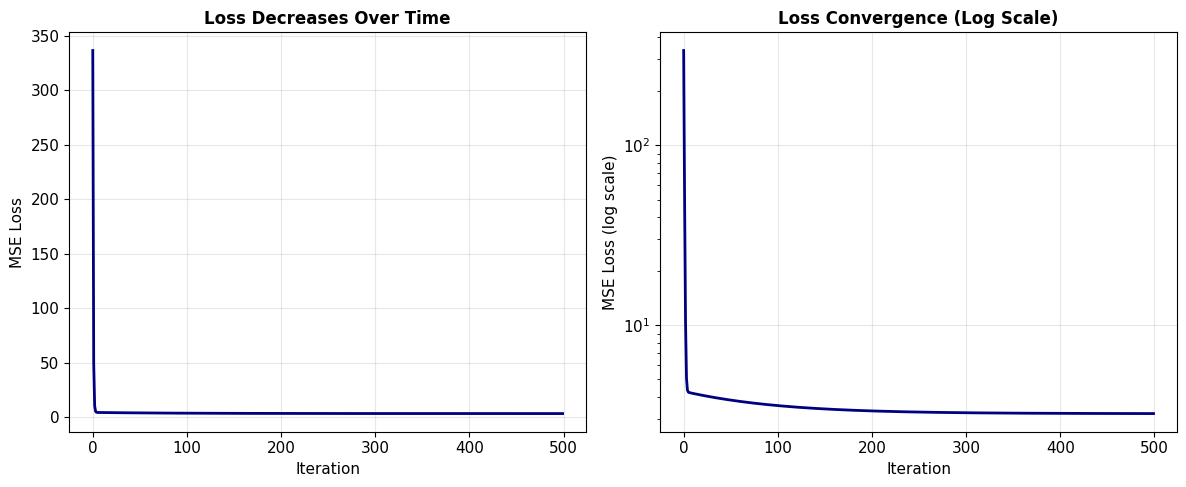

In [10]:
# Plot loss over iterations
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history['loss'], linewidth=2, color='navy')
plt.xlabel('Iteration', fontsize=11)
plt.ylabel('MSE Loss', fontsize=11)
plt.title('Loss Decreases Over Time', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history['loss'], linewidth=2, color='navy')
plt.xlabel('Iteration', fontsize=11)
plt.ylabel('MSE Loss (log scale)', fontsize=11)
plt.title('Loss Convergence (Log Scale)', fontsize=12, fontweight='bold')
plt.yscale('log')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Execute the following code:

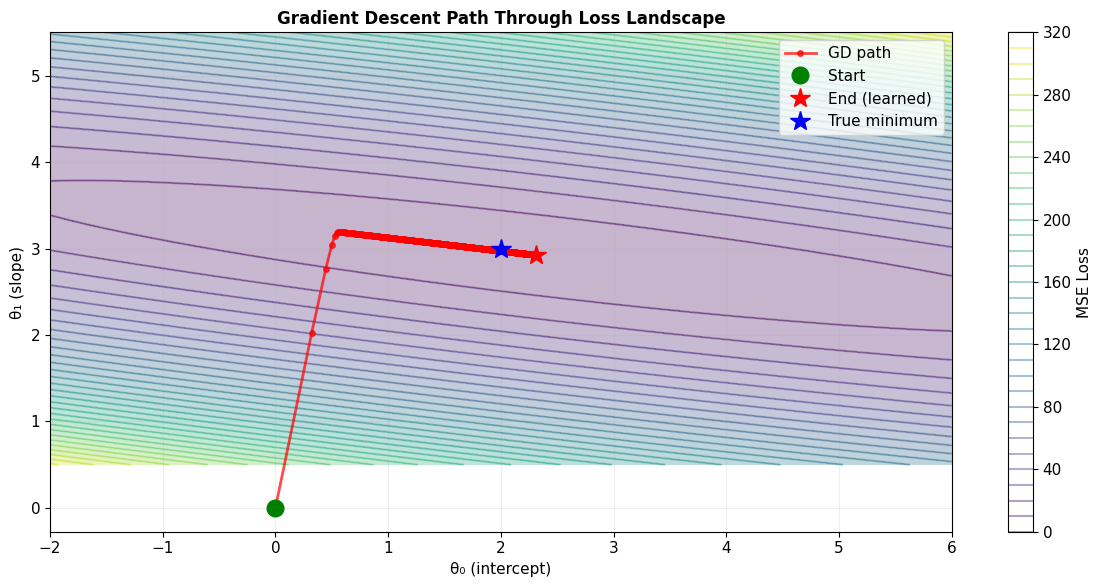

In [11]:
# Plot the path through parameter space
plt.figure(figsize=(12, 6))

# Contour plot
contour = plt.contour(theta_0_grid, theta_1_grid, mse_grid, levels=30, cmap=cm.viridis, alpha=0.4)
plt.contourf(theta_0_grid, theta_1_grid, mse_grid, levels=30, cmap=cm.viridis, alpha=0.3)

# Plot gradient descent path
theta_0_history = [0.0] + history['theta_0']
theta_1_history = [0.0] + history['theta_1']

plt.plot(theta_0_history, theta_1_history, 'o-', color='red', 
         linewidth=2, markersize=4, label='GD path', alpha=0.7)
plt.plot(theta_0_history[0], theta_1_history[0], 'go', markersize=12, label='Start')
plt.plot(theta_0_history[-1], theta_1_history[-1], 'r*', markersize=15, label='End (learned)')
plt.plot(2, 3, 'b*', markersize=15, label='True minimum')

plt.xlabel('θ₀ (intercept)', fontsize=11)
plt.ylabel('θ₁ (slope)', fontsize=11)
plt.title('Gradient Descent Path Through Loss Landscape', fontsize=12, fontweight='bold')
plt.legend(loc='upper right')
plt.colorbar(contour, label='MSE Loss')
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

### Key Observations

1. **Path**: Gradient descent takes a curved path, not a straight line to the minimum
2. **Perpendicular to contours**: Each step is perpendicular to the contour lines (steepest descent)
3. **Fast at first**: Big steps when gradient is large (far from minimum)
4. **Slows down**: Smaller steps when gradient is small (near minimum)

### The Effect of Learning Rate

Let's experiment with different learning rates!

/home/tsilva/repos/tsilva/aiml-notebooks/.venv/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/tmp/ipykernel_96230/1167727064.py:18: RuntimeWarning: overflow encountered in square
  mse = (1/n) * np.sum(errors**2)
/tmp/ipykernel_96230/3558582491.py:39: RuntimeWarning: invalid value encountered in scalar subtract
  theta_1 = theta_1 - learning_rate * grad_theta_1


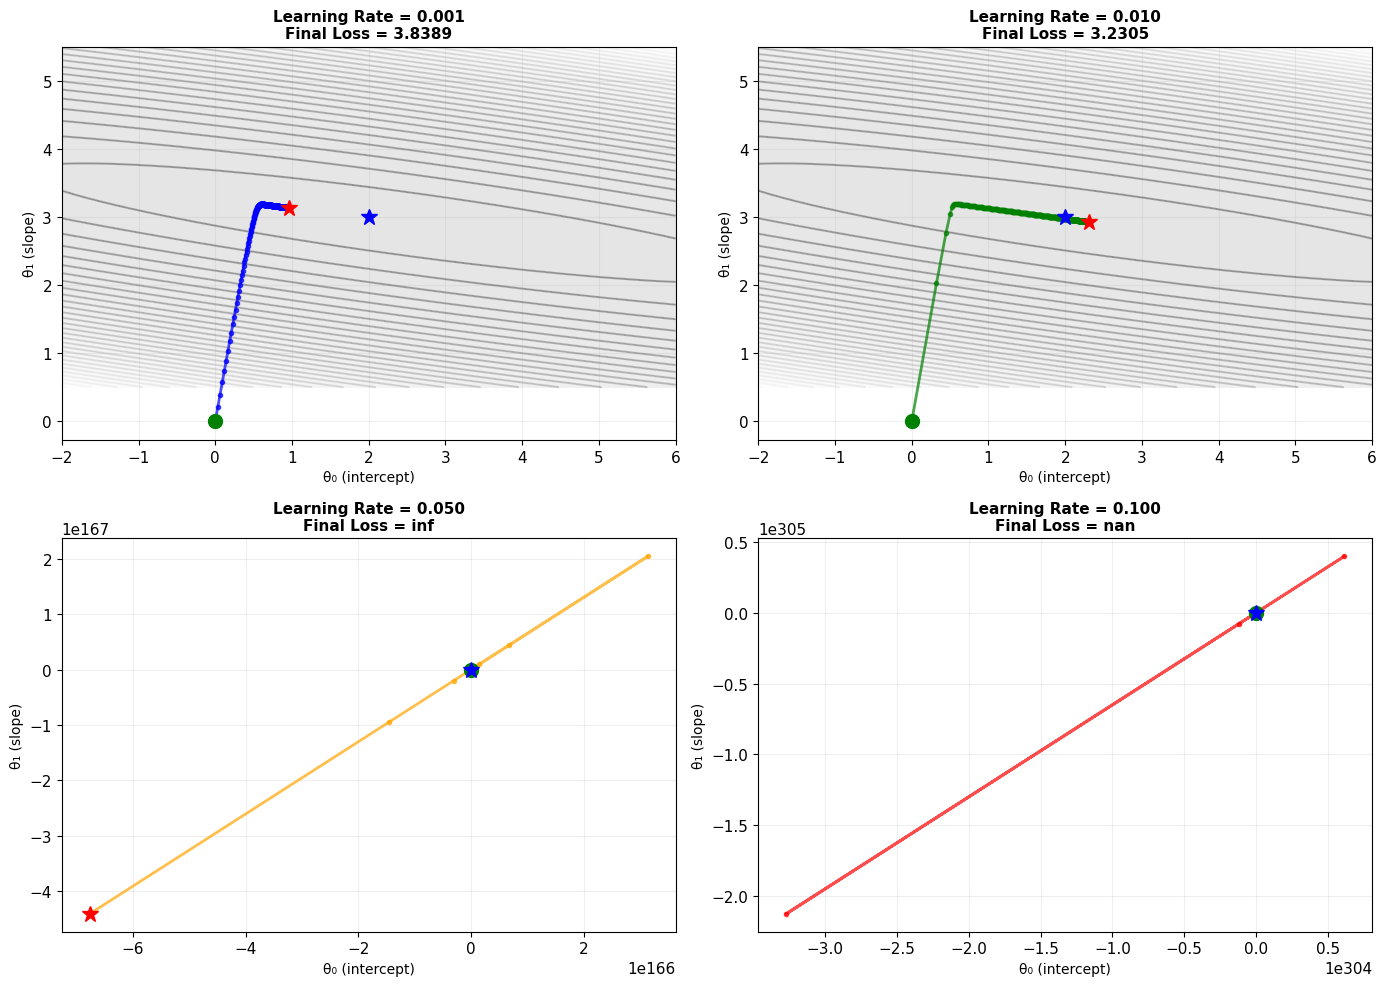


🔍 Observations:
  • Too small (0.001): Very slow convergence, many iterations needed
  • Just right (0.01): Smooth, efficient convergence
  • Moderate (0.05): Faster but might oscillate
  • Too large (0.1): Can overshoot and oscillate


In [12]:
# Try different learning rates
learning_rates = [0.001, 0.01, 0.05, 0.1]
colors = ['blue', 'green', 'orange', 'red']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (lr, color) in enumerate(zip(learning_rates, colors)):
    ax = axes[idx]
    
    # Run gradient descent
    theta_0_lr, theta_1_lr, history_lr = gradient_descent(
        X, y,
        theta_0_init=0.0,
        theta_1_init=0.0,
        learning_rate=lr,
        num_iterations=500,
        verbose=False
    )
    
    # Plot contours
    ax.contour(theta_0_grid, theta_1_grid, mse_grid, levels=30, cmap=cm.gray, alpha=0.3)
    ax.contourf(theta_0_grid, theta_1_grid, mse_grid, levels=30, cmap=cm.gray, alpha=0.1)
    
    # Plot path
    theta_0_hist = [0.0] + history_lr['theta_0']
    theta_1_hist = [0.0] + history_lr['theta_1']
    ax.plot(theta_0_hist, theta_1_hist, 'o-', color=color, linewidth=2, markersize=3, alpha=0.7)
    ax.plot(theta_0_hist[0], theta_1_hist[0], 'go', markersize=10)
    ax.plot(theta_0_hist[-1], theta_1_hist[-1], 'r*', markersize=12)
    ax.plot(2, 3, 'b*', markersize=12)
    
    final_loss = history_lr['loss'][-1]
    ax.set_xlabel('θ₀ (intercept)', fontsize=10)
    ax.set_ylabel('θ₁ (slope)', fontsize=10)
    ax.set_title(f'Learning Rate = {lr:.3f}\nFinal Loss = {final_loss:.4f}', 
                 fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

print("\n🔍 Observations:")
print("  • Too small (0.001): Very slow convergence, many iterations needed")
print("  • Just right (0.01): Smooth, efficient convergence")
print("  • Moderate (0.05): Faster but might oscillate")
print("  • Too large (0.1): Can overshoot and oscillate")

### 🧪 Interactive Experiment

**Try this**: Change the learning rates in the cell above to even more extreme values like 0.0001 or 0.2. What happens?

**Q:** What would happen with a learning rate of 1.0? Try it!

## Part 10: The Analytical Solution

Here's a surprising fact: For linear regression, we don't actually need gradient descent! There's a **closed-form solution** that gives us the exact answer in one step.

### The Normal Equation

For the general case with multiple features, if we write:
- $X$ = design matrix with a column of ones for the intercept (shape: $n \times 2$)
- $y$ = targets (shape: $n \times 1$)
- $\theta$ = parameters $[\theta_0, \theta_1]^T$ (shape: $2 \times 1$)

The optimal parameters are:

$$\theta^* = (X^T X)^{-1} X^T y$$

This is called the **Normal Equation** or **Ordinary Least Squares (OLS)** solution.

### Why Does This Work?

The normal equation comes from setting the gradient to zero and solving directly:

$$\nabla_\theta J(\theta) = 0$$

Since MSE is convex (bowl-shaped), this gives us the global minimum!

### Advantages
- ✅ Exact solution (no iterations needed)
- ✅ No learning rate to tune
- ✅ No convergence issues

### Disadvantages
- ❌ Requires computing $(X^T X)^{-1}$ which is $O(n^3)$ for $n$ features
- ❌ Doesn't work well when $n$ features is very large (e.g., > 10,000)
- ❌ Doesn't extend to more complex models (neural networks, etc.)

## Part 11: Implementing the Analytical Solution

In [13]:
def analytical_solution(X, y):
    """
    Compute optimal parameters using the normal equation.
    
    Args:
        X: features (n,)
        y: targets (n,)
    
    Returns:
        theta_0: optimal intercept
        theta_1: optimal slope
    """
    n = len(X)
    
    # Create design matrix: add column of ones for intercept
    X_design = np.column_stack([np.ones(n), X])  # shape: (n, 2)
    
    # Normal equation: theta = (X^T X)^-1 X^T y
    theta = np.linalg.inv(X_design.T @ X_design) @ X_design.T @ y
    
    theta_0 = theta[0]
    theta_1 = theta[1]
    
    return theta_0, theta_1

# Compute analytical solution
print("Computing analytical solution...\n")
theta_0_analytical, theta_1_analytical = analytical_solution(X, y)

print("Analytical Solution (Normal Equation):")
print(f"  θ₀ (intercept) = {theta_0_analytical:.4f}")
print(f"  θ₁ (slope)     = {theta_1_analytical:.4f}")

print("\nGradient Descent Solution:")
print(f"  θ₀ (intercept) = {theta_0_gd:.4f}")
print(f"  θ₁ (slope)     = {theta_1_gd:.4f}")

print("\nTrue Parameters:")
print(f"  θ₀ (intercept) = 2.0000")
print(f"  θ₁ (slope)     = 3.0000")

# Compute losses
loss_analytical = compute_mse(X, y, theta_0_analytical, theta_1_analytical)
loss_gd = compute_mse(X, y, theta_0_gd, theta_1_gd)

print("\nFinal Losses:")
print(f"  Analytical: {loss_analytical:.6f}")
print(f"  Gradient Descent: {loss_gd:.6f}")
print(f"  Difference: {abs(loss_analytical - loss_gd):.9f}")

Computing analytical solution...

Analytical Solution (Normal Equation):
  θ₀ (intercept) = 2.4302
  θ₁ (slope)     = 2.9080

Gradient Descent Solution:
  θ₀ (intercept) = 2.3101
  θ₁ (slope)     = 2.9265

True Parameters:
  θ₀ (intercept) = 2.0000
  θ₁ (slope)     = 3.0000

Final Losses:
  Analytical: 3.226338
  Gradient Descent: 3.230431
  Difference: 0.004092297


### Key Observation

The analytical solution gives us the **exact** minimum! Gradient descent gets very close, but there's always a tiny bit of error (which can be reduced with more iterations or better learning rate).

## Part 12: Comparing the Approaches

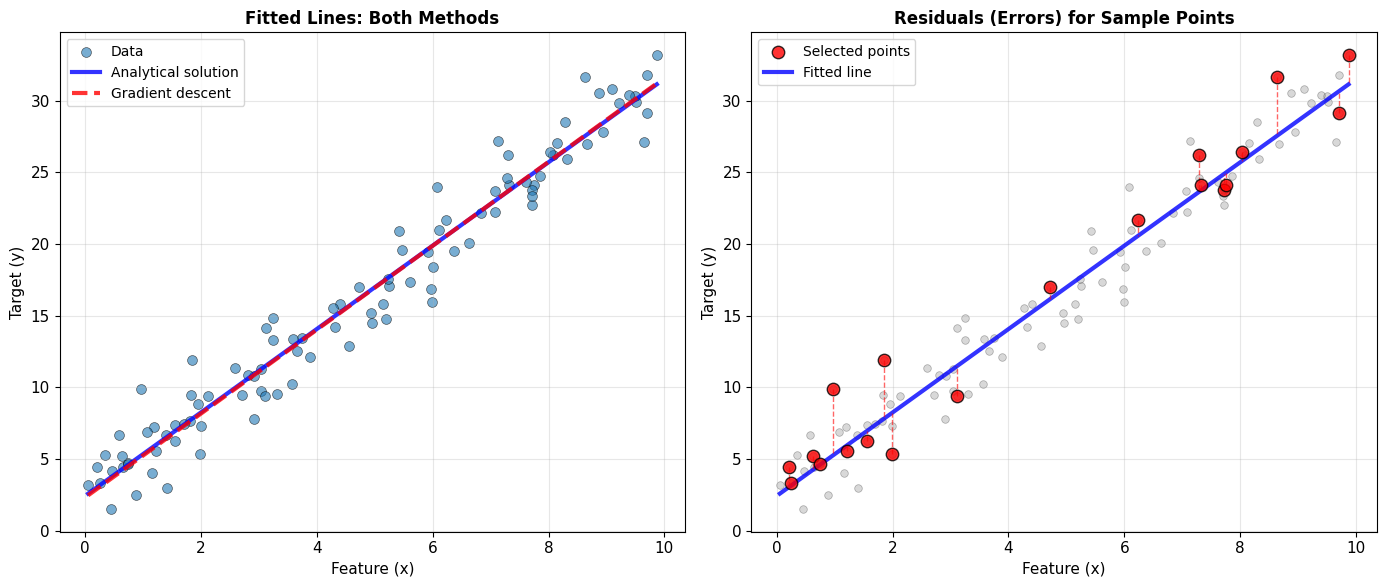

Red dashed lines = residuals (prediction errors)
MSE minimizes the sum of squared residuals!


In [14]:
# Visualize both solutions on the data
plt.figure(figsize=(14, 6))

x_line = np.linspace(X.min(), X.max(), 100)

plt.subplot(1, 2, 1)
plt.scatter(X, y, alpha=0.6, s=50, edgecolors='black', linewidth=0.5, label='Data')
y_line_analytical = theta_0_analytical + theta_1_analytical * x_line
y_line_gd = theta_0_gd + theta_1_gd * x_line
plt.plot(x_line, y_line_analytical, 'b-', linewidth=3, label='Analytical solution', alpha=0.8)
plt.plot(x_line, y_line_gd, 'r--', linewidth=3, label='Gradient descent', alpha=0.8)
plt.xlabel('Feature (x)', fontsize=11)
plt.ylabel('Target (y)', fontsize=11)
plt.title('Fitted Lines: Both Methods', fontsize=12, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
# Plot a few residuals (errors)
sample_indices = np.random.choice(len(X), size=20, replace=False)
X_sample = X[sample_indices]
y_sample = y[sample_indices]
y_pred_sample = theta_0_analytical + theta_1_analytical * X_sample

plt.scatter(X, y, alpha=0.3, s=30, edgecolors='black', linewidth=0.5, color='gray')
plt.scatter(X_sample, y_sample, alpha=0.8, s=80, edgecolors='black', linewidth=1, 
           color='red', label='Selected points', zorder=5)
plt.plot(x_line, y_line_analytical, 'b-', linewidth=3, label='Fitted line', alpha=0.8)

# Draw residuals
for x_pt, y_pt, y_pred_pt in zip(X_sample, y_sample, y_pred_sample):
    plt.plot([x_pt, x_pt], [y_pt, y_pred_pt], 'r--', linewidth=1, alpha=0.6)

plt.xlabel('Feature (x)', fontsize=11)
plt.ylabel('Target (y)', fontsize=11)
plt.title('Residuals (Errors) for Sample Points', fontsize=12, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Red dashed lines = residuals (prediction errors)")
print("MSE minimizes the sum of squared residuals!")

### Comparison Summary

| Aspect | Gradient Descent | Analytical Solution |
|--------|-----------------|---------------------|
| **Speed (small data)** | Slower (iterative) | Faster (one step) |
| **Speed (large features)** | Faster | Slower (matrix inversion) |
| **Accuracy** | Approximate | Exact |
| **Hyperparameters** | Needs learning rate, iterations | None |
| **Scalability** | Scales to any # features | Struggles with many features |
| **Extensibility** | Works for complex models | Only for linear models |
| **When to use** | Large-scale, neural networks | Small-scale, theoretical |

### 🤔 Reflection Questions

**Q1:** If you had 1 million features, which method would you use?

**Q2:** For a simple problem with 10 features, which method would you prefer?

**Q3:** Why do you think gradient descent is the foundation of deep learning, not the analytical solution?

## Part 13: Multivariate Linear Regression

So far we've worked with **one feature** ($x$). But in reality, we often have **multiple features**!

Example: Predicting house price from:
- Square footage
- Number of bedrooms
- Age of house
- Distance to city center

### The General Form

With $d$ features:

$$h_\theta(x) = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \cdots + \theta_d x_d$$

In vector form:

$$h_\theta(x) = \theta^T x$$

where $x = [1, x_1, x_2, \ldots, x_d]^T$ (we add 1 for the intercept).

### Good News!

Everything we learned extends naturally:
- **MSE loss**: Same formula, just sum over all examples
- **Gradient descent**: Same algorithm, just more parameters to update
- **Analytical solution**: Same normal equation!

In [15]:
# Generate multivariate data (2 features)
def generate_multivariate_data(n=100, theta_true=None, noise_std=2.0):
    """
    Generate data with multiple features.
    
    Args:
        n: number of samples
        theta_true: true parameters [theta_0, theta_1, theta_2, ...]
        noise_std: standard deviation of noise
    """
    if theta_true is None:
        theta_true = np.array([1.0, 2.0, -1.5])  # intercept + 2 features
    
    d = len(theta_true) - 1  # number of features
    
    # Generate random features
    X = np.random.uniform(0, 10, size=(n, d))
    
    # Add intercept column
    X_design = np.column_stack([np.ones(n), X])
    
    # Generate targets
    y = X_design @ theta_true + np.random.normal(0, noise_std, n)
    
    return X, y, theta_true

# Generate data
X_multi, y_multi, theta_true_multi = generate_multivariate_data(n=200)

print(f"Generated multivariate dataset:")
print(f"  X shape: {X_multi.shape} (200 samples, 2 features)")
print(f"  y shape: {y_multi.shape}")
print(f"  True parameters: {theta_true_multi}")

Generated multivariate dataset:
  X shape: (200, 2) (200 samples, 2 features)
  y shape: (200,)
  True parameters: [ 1.   2.  -1.5]


Execute the following code:

In [16]:
# Implement multivariate gradient descent
def gradient_descent_multivariate(X, y, learning_rate=0.01, num_iterations=1000):
    """
    Gradient descent for multivariate linear regression.
    
    Args:
        X: features (n, d)
        y: targets (n,)
        learning_rate: step size
        num_iterations: number of iterations
    
    Returns:
        theta: learned parameters (d+1,) including intercept
        losses: loss history
    """
    n, d = X.shape
    
    # Add intercept column
    X_design = np.column_stack([np.ones(n), X])
    
    # Initialize parameters
    theta = np.zeros(d + 1)
    
    losses = []
    
    for iteration in range(num_iterations):
        # Predictions
        predictions = X_design @ theta
        
        # Errors
        errors = predictions - y
        
        # Loss
        loss = (1/n) * np.sum(errors**2)
        losses.append(loss)
        
        # Gradients (vectorized!)
        gradients = (2/n) * X_design.T @ errors
        
        # Update
        theta = theta - learning_rate * gradients
        
        if iteration % 200 == 0:
            print(f"Iteration {iteration:4d}: Loss = {loss:8.4f}")
    
    return theta, losses

# Analytical solution for multivariate case
def analytical_solution_multivariate(X, y):
    """Analytical solution for multivariate regression."""
    n = len(y)
    X_design = np.column_stack([np.ones(n), X])
    theta = np.linalg.inv(X_design.T @ X_design) @ X_design.T @ y
    return theta

# Run both methods
print("\nGradient Descent (Multivariate):\n")
theta_gd_multi, losses_multi = gradient_descent_multivariate(
    X_multi, y_multi, learning_rate=0.01, num_iterations=1000
)

print("\nAnalytical Solution (Multivariate):\n")
theta_analytical_multi = analytical_solution_multivariate(X_multi, y_multi)

print("\n" + "="*60)
print("RESULTS COMPARISON")
print("="*60)
print(f"\nTrue parameters:        {theta_true_multi}")
print(f"Gradient Descent:       {theta_gd_multi}")
print(f"Analytical Solution:    {theta_analytical_multi}")
print("\n✓ Both methods recover the true parameters (approximately)!")


Gradient Descent (Multivariate):

Iteration    0: Loss =  59.5033
Iteration  200: Loss =   4.0901
Iteration  400: Loss =   4.0392
Iteration  600: Loss =   4.0256
Iteration  800: Loss =   4.0219

Analytical Solution (Multivariate):


RESULTS COMPARISON

True parameters:        [ 1.   2.  -1.5]
Gradient Descent:       [ 1.22691883  1.97299664 -1.52351814]
Analytical Solution:    [ 1.27313317  1.96946213 -1.52785739]

✓ Both methods recover the true parameters (approximately)!


## Part 14: Feature Scaling

When features have very different scales, gradient descent can struggle!

### The Problem

Imagine predicting house price from:
- **Feature 1**: Square footage (range: 500 - 5000)
- **Feature 2**: Number of bedrooms (range: 1 - 5)

The first feature varies much more than the second. This creates an elongated (elliptical) loss landscape, making gradient descent take many small steps.

### The Solution: Standardization

Transform each feature to have:
- **Mean = 0**
- **Standard deviation = 1**

$$x_{\text{scaled}} = \frac{x - \mu}{\sigma}$$

where $\mu$ is the mean and $\sigma$ is the standard deviation.

In [17]:
# Generate data with very different feature scales
n = 200
X_unscaled = np.column_stack([
    np.random.uniform(500, 5000, n),    # Square footage: large scale
    np.random.uniform(1, 5, n)          # Bedrooms: small scale
])
theta_true_scale = np.array([50000, 100, 20000])  # intercept, weight1, weight2
X_design_unscaled = np.column_stack([np.ones(n), X_unscaled])
y_unscaled = X_design_unscaled @ theta_true_scale + np.random.normal(0, 5000, n)

# Standardize features
X_scaled = (X_unscaled - X_unscaled.mean(axis=0)) / X_unscaled.std(axis=0)

print("Feature statistics (BEFORE scaling):")
print(f"  Feature 1: mean={X_unscaled[:, 0].mean():.1f}, std={X_unscaled[:, 0].std():.1f}")
print(f"  Feature 2: mean={X_unscaled[:, 1].mean():.1f}, std={X_unscaled[:, 1].std():.1f}")

print("\nFeature statistics (AFTER scaling):")
print(f"  Feature 1: mean={X_scaled[:, 0].mean():.6f}, std={X_scaled[:, 0].std():.6f}")
print(f"  Feature 2: mean={X_scaled[:, 1].mean():.6f}, std={X_scaled[:, 1].std():.6f}")

Feature statistics (BEFORE scaling):
  Feature 1: mean=2843.6, std=1324.6
  Feature 2: mean=3.0, std=1.2

Feature statistics (AFTER scaling):
  Feature 1: mean=0.000000, std=1.000000
  Feature 2: mean=-0.000000, std=1.000000


Execute the following code:

Running gradient descent WITHOUT feature scaling...
Iteration    0: Loss = 173916850747.0306
Iteration  200: Loss = 80647158614.9030
Iteration  400: Loss = 38233333523.7625
Iteration  600: Loss = 18945904384.4842
Iteration  800: Loss = 10175063022.4090

Running gradient descent WITH feature scaling...
Iteration    0: Loss = 173916850747.0306
Iteration  200: Loss = 26820841.8797
Iteration  400: Loss = 26820841.8797
Iteration  600: Loss = 26820841.8797
Iteration  800: Loss = 26820841.8797


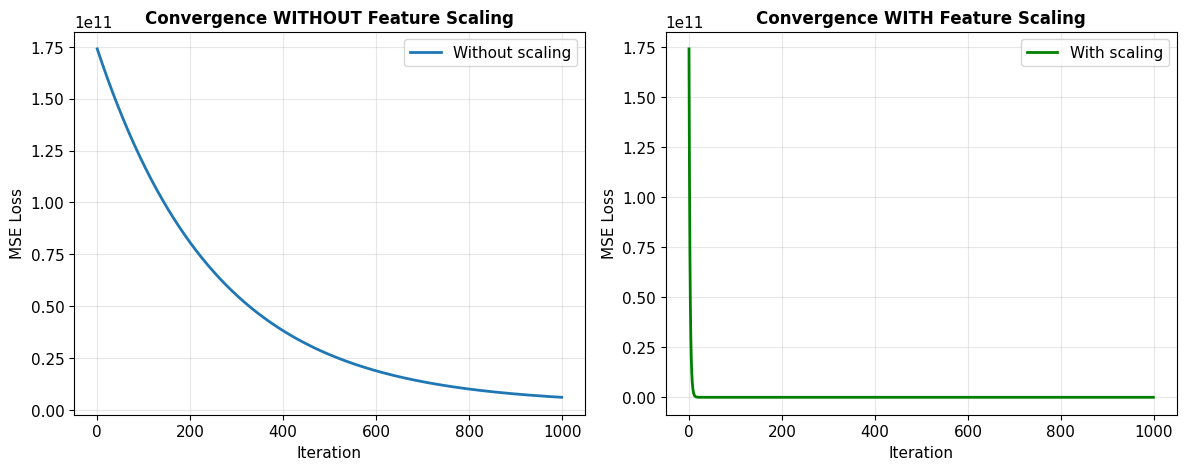


🎯 Key Insight: Feature scaling makes gradient descent converge MUCH faster!


In [18]:
# Compare gradient descent WITH and WITHOUT scaling
print("Running gradient descent WITHOUT feature scaling...")
theta_unscaled, losses_unscaled = gradient_descent_multivariate(
    X_unscaled, y_unscaled, learning_rate=1e-10, num_iterations=1000
)

print("\nRunning gradient descent WITH feature scaling...")
theta_scaled, losses_scaled = gradient_descent_multivariate(
    X_scaled, y_unscaled, learning_rate=0.1, num_iterations=1000
)

# Plot convergence comparison
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(losses_unscaled, linewidth=2, label='Without scaling')
plt.xlabel('Iteration', fontsize=11)
plt.ylabel('MSE Loss', fontsize=11)
plt.title('Convergence WITHOUT Feature Scaling', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(losses_scaled, linewidth=2, color='green', label='With scaling')
plt.xlabel('Iteration', fontsize=11)
plt.ylabel('MSE Loss', fontsize=11)
plt.title('Convergence WITH Feature Scaling', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

print("\n🎯 Key Insight: Feature scaling makes gradient descent converge MUCH faster!")

### Why Does Scaling Help?

1. **Equal treatment**: All features contribute equally to the gradient
2. **Circular contours**: Loss landscape becomes more circular (not elongated)
3. **Faster convergence**: Can use larger learning rates without instability
4. **Numerical stability**: Avoids very large or very small numbers

**Best Practice**: Always standardize features before using gradient descent!

## Part 15: Practical Considerations

### Convergence Criteria

How do we know when to stop gradient descent?

**Options**:
1. **Fixed iterations**: Run for N iterations (simple but wasteful)
2. **Loss threshold**: Stop when loss < threshold (requires knowing target loss)
3. **Gradient magnitude**: Stop when $||\nabla J|| < \epsilon$ (at minimum)
4. **Loss change**: Stop when $|J^{(t)} - J^{(t-1)}| < \epsilon$ (most common)

### Learning Rate Schedules

Instead of fixed learning rate, we can:
- **Decay**: Start large, gradually decrease
- **Adaptive**: Adjust based on gradient (e.g., Adam optimizer)

### Numerical Stability

Watch out for:
- **Overflow/underflow**: Very large or small numbers
- **Singular matrices**: $(X^T X)$ might not be invertible
- **Ill-conditioning**: Small changes in input → large changes in output

In [19]:
# Implement gradient descent with convergence criterion
def gradient_descent_with_convergence(X, y, learning_rate=0.01, 
                                     max_iterations=10000, tolerance=1e-6):
    """
    Gradient descent with automatic convergence detection.
    """
    n, d = X.shape
    X_design = np.column_stack([np.ones(n), X])
    theta = np.zeros(d + 1)
    
    losses = []
    prev_loss = float('inf')
    
    for iteration in range(max_iterations):
        predictions = X_design @ theta
        errors = predictions - y
        loss = (1/n) * np.sum(errors**2)
        losses.append(loss)
        
        # Check convergence
        if abs(prev_loss - loss) < tolerance:
            print(f"✓ Converged after {iteration} iterations!")
            print(f"  Final loss: {loss:.6f}")
            print(f"  Loss change: {abs(prev_loss - loss):.2e} < tolerance ({tolerance:.2e})")
            break
        
        gradients = (2/n) * X_design.T @ errors
        theta = theta - learning_rate * gradients
        prev_loss = loss
    else:
        print(f"⚠ Reached max iterations ({max_iterations}) without full convergence")
    
    return theta, losses

# Test it
print("Running gradient descent with automatic convergence detection...\n")
theta_converged, losses_converged = gradient_descent_with_convergence(
    X_multi, y_multi, learning_rate=0.01, max_iterations=10000, tolerance=1e-6
)

Running gradient descent with automatic convergence detection...

✓ Converged after 1131 iterations!
  Final loss: 4.020752
  Loss change: 9.94e-07 < tolerance (1.00e-06)


## Part 16: Interactive Experiments

Now it's your turn to explore! Try these experiments:

### 🧪 Experiment 1: Learning Rate Extremes
Go back to the learning rate comparison section and try:
- Very small: 0.0001
- Very large: 0.5, 1.0, 2.0

**Q:** What happens with learning_rate = 2.0? Does it converge?

### 🧪 Experiment 2: Noise Levels
Modify the `generate_1d_data` function to use different noise levels:
- Low noise: `noise_std = 0.5`
- High noise: `noise_std = 5.0`

**Q:** How does noise affect the final MSE? Can we ever get MSE = 0?

### 🧪 Experiment 3: More Features
Generate data with 5 or 10 features instead of 2.

**Q:** Does gradient descent still work? How about the analytical solution?

### 🧪 Experiment 4: Dataset Size
Try with:
- Small dataset: n = 20
- Large dataset: n = 10,000

**Q:** Which method is faster for each case?

High Noise Experiment:
  Learned: θ₀=1.3931, θ₁=3.1042
  True:    θ₀=2.0000, θ₁=3.0000
  Final MSE: 25.6601


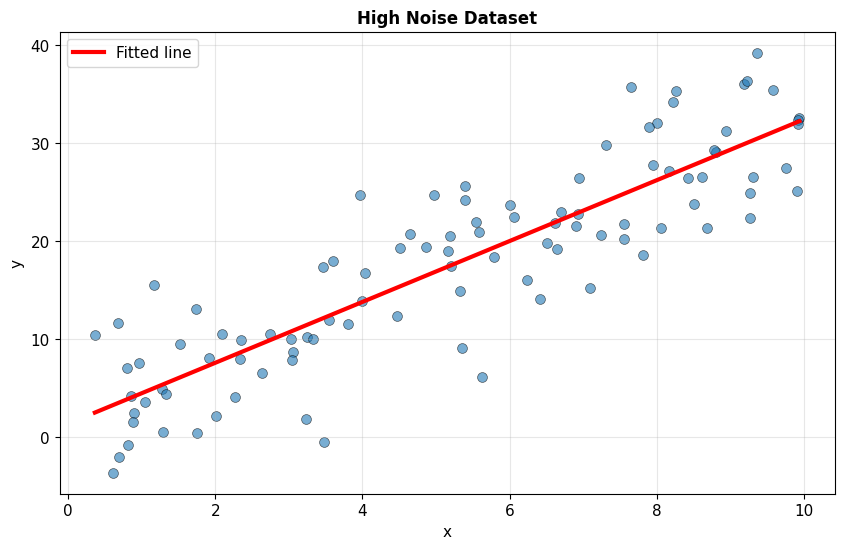


💡 Try your own experiments above!


In [20]:
# Experiment space - try your own experiments here!

# Example: High noise experiment
X_noisy, y_noisy = generate_1d_data(n=100, theta_0_true=2.0, theta_1_true=3.0, noise_std=5.0)

theta_0_noisy, theta_1_noisy = analytical_solution(X_noisy, y_noisy)
loss_noisy = compute_mse(X_noisy, y_noisy, theta_0_noisy, theta_1_noisy)

print("High Noise Experiment:")
print(f"  Learned: θ₀={theta_0_noisy:.4f}, θ₁={theta_1_noisy:.4f}")
print(f"  True:    θ₀=2.0000, θ₁=3.0000")
print(f"  Final MSE: {loss_noisy:.4f}")

# Visualize
plt.figure(figsize=(10, 6))
plt.scatter(X_noisy, y_noisy, alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
x_line = np.linspace(X_noisy.min(), X_noisy.max(), 100)
y_line = theta_0_noisy + theta_1_noisy * x_line
plt.plot(x_line, y_line, 'r-', linewidth=3, label='Fitted line')
plt.xlabel('x', fontsize=11)
plt.ylabel('y', fontsize=11)
plt.title('High Noise Dataset', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\n💡 Try your own experiments above!")

## Part 17: Summary & Key Takeaways

Congratulations! You've built linear regression from scratch and developed deep intuitions about how it works.

### 🎯 What You've Learned

1. **Linear Regression Fundamentals**
   - Hypothesis: $h_\theta(x) = \theta_0 + \theta_1 x$
   - Goal: Find best parameters $\theta$ that fit the data

2. **Mean Squared Error (MSE)**
   - Measures average squared prediction error
   - Creates a convex (bowl-shaped) loss landscape
   - Has a unique global minimum

3. **Gradient Descent**
   - Iterative optimization algorithm
   - Follow the negative gradient (downhill)
   - Learning rate controls step size
   - Works for any differentiable loss function

4. **Analytical Solution**
   - Normal equation: $\theta^* = (X^T X)^{-1} X^T y$
   - Gives exact answer in one step
   - Only for linear regression (doesn't generalize)
   - Slow for many features ($O(n^3)$)

5. **Practical Insights**
   - Feature scaling is crucial for gradient descent
   - Learning rate must be tuned carefully
   - Convergence criteria prevent wasted computation
   - Noise in data limits achievable performance

### 🚀 What's Next?

Now that you understand linear regression deeply, you can:
- **Learn regularization** (Ridge, Lasso) to prevent overfitting
- **Study logistic regression** for classification
- **Explore neural networks** (they're just fancy gradient descent!)
- **Apply to real data** (housing, finance, biology, etc.)

### 💡 The Big Picture

Linear regression might seem simple, but it teaches fundamental concepts that power all of machine learning:
- Loss functions
- Gradient-based optimization
- Train/test evaluation
- Hyperparameter tuning

**Master the basics, and the advanced stuff becomes much easier!**

---

### 🤔 Final Reflection Questions

1. Can you explain to someone else (in plain English) how gradient descent works?
2. When would you use gradient descent vs. the analytical solution?
3. What happens if you try to fit a linear model to non-linear data?
4. How would you extend this to polynomial regression ($y = \theta_0 + \theta_1 x + \theta_2 x^2 + \cdots$)?

---

**Well done!** 🎉 You now have strong, solid intuitions about linear regression from first principles.